# Bearing Fault Classification
Vibration signal analysis and fault detection using the CWRU Bearing Dataset.
Fault types: normal, inner race, ball, outer race (0.007" diameter faults, drive end, 12kHz).

In [1]:
# Only needed in Colab - see environment.yml for local use
!pip install -q scipy numpy pandas scikit-learn matplotlib seaborn

In [19]:
import os
import urllib.request

import numpy as np
import pandas as pd
import scipy.io
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import json

print("scipy:", scipy.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

print("scipy:", scipy.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

scipy: 1.16.3
numpy: 2.0.2
sklearn: 1.6.1
scipy: 1.16.3
numpy: 2.0.2
sklearn: 1.6.1


## Data Download

In [3]:
os.makedirs("data/raw", exist_ok=True)

base_url = "https://engineering.case.edu/sites/default/files/"

files = {
    "97.mat":  "normal_0.mat",
    "98.mat":  "normal_1.mat",
    "99.mat":  "normal_2.mat",
    "100.mat": "normal_3.mat",
    "105.mat": "inner_race_0.mat",
    "106.mat": "inner_race_1.mat",
    "107.mat": "inner_race_2.mat",
    "108.mat": "inner_race_3.mat",
    "118.mat": "ball_0.mat",
    "119.mat": "ball_1.mat",
    "120.mat": "ball_2.mat",
    "121.mat": "ball_3.mat",
    "130.mat": "outer_race_0.mat",
    "131.mat": "outer_race_1.mat",
    "132.mat": "outer_race_2.mat",
}

failed = []

for original, renamed in files.items():
    url = base_url + original
    dest = f"data/raw/{renamed}"
    if not os.path.exists(dest):
        print(f"Downloading {original} -> {renamed}")
        urllib.request.urlretrieve(url, dest)

    # Validate immediately after download or if already exists
    try:
        scipy.io.loadmat(dest)
        print(f"OK    {renamed}")
    except Exception as e:
        print(f"ERROR {renamed} -- {e}")
        failed.append((url, dest))

# Retry failed downloads once
if failed:
    print(f"\nRetrying {len(failed)} failed file(s)...")
    for url, dest in failed:
        try:
            urllib.request.urlretrieve(url, dest)
            scipy.io.loadmat(dest)
            print(f"OK on retry: {dest}")
        except Exception as e:
            print(f"FAILED on retry: {dest} -- {e}")
else:
    print("\nAll files downloaded and validated successfully.")

OK    normal_0.mat
OK    normal_1.mat
OK    normal_2.mat
OK    normal_3.mat
OK    inner_race_0.mat
OK    inner_race_1.mat
OK    inner_race_2.mat
OK    inner_race_3.mat
OK    ball_0.mat
OK    ball_1.mat
OK    ball_2.mat
OK    ball_3.mat
OK    outer_race_0.mat
OK    outer_race_1.mat
OK    outer_race_2.mat

All files downloaded and validated successfully.


## Data Exploration


In [4]:
# Inspect normal file
sample = scipy.io.loadmat("data/raw/normal_0.mat")

for key, value in sample.items():
    if not key.startswith("_"):
        print(f"{key}: type={type(value)}, shape={value.shape}")

X097_DE_time: type=<class 'numpy.ndarray'>, shape=(243938, 1)
X097_FE_time: type=<class 'numpy.ndarray'>, shape=(243938, 1)
X097RPM: type=<class 'numpy.ndarray'>, shape=(1, 1)


In [5]:
# Inspect a fault file
sample_fault = scipy.io.loadmat("data/raw/inner_race_0.mat")

for key, value in sample_fault.items():
    if not key.startswith("_"):
        print(f"{key}: type={type(value)}, shape={value.shape}")

X105_DE_time: type=<class 'numpy.ndarray'>, shape=(121265, 1)
X105_FE_time: type=<class 'numpy.ndarray'>, shape=(121265, 1)
X105_BA_time: type=<class 'numpy.ndarray'>, shape=(121265, 1)
X105RPM: type=<class 'numpy.ndarray'>, shape=(1, 1)


## Data Loader

In [6]:
def load_signal(filepath):
    """Load drive end accelerometer signal from a CWRU .mat file."""
    mat = scipy.io.loadmat(filepath)
    key = [k for k in mat.keys() if k.endswith("_DE_time")][0]
    signal = mat[key].flatten()
    return signal

# Test it
signal = load_signal("data/raw/normal_0.mat")
print(f"Signal length: {len(signal)}")
print(f"Min: {signal.min():.4f}, Max: {signal.max():.4f}, Mean: {signal.mean():.4f}")

Signal length: 243938
Min: -0.2866, Max: 0.3113, Mean: 0.0126


### Raw signal visualisation

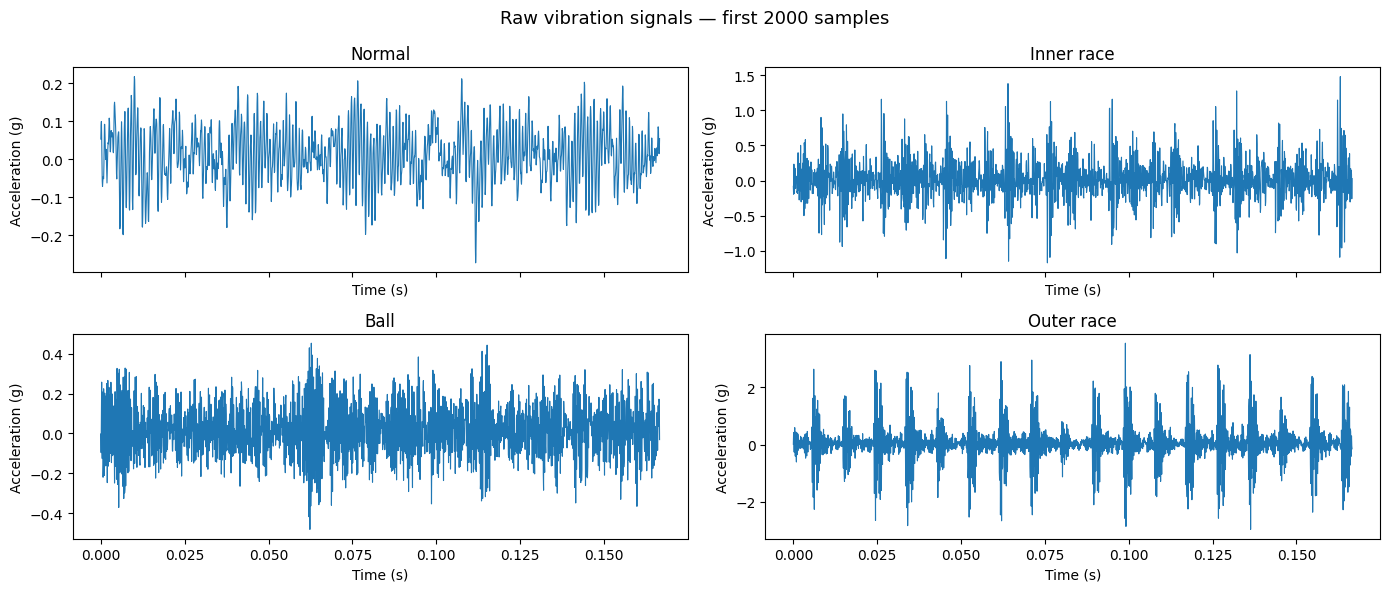

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)

files = {
    "Normal":      "data/raw/normal_0.mat",
    "Inner race":  "data/raw/inner_race_0.mat",
    "Ball":        "data/raw/ball_0.mat",
    "Outer race":  "data/raw/outer_race_0.mat",
}

for ax, (label, filepath) in zip(axes.flatten(), files.items()):
    signal = load_signal(filepath)
    time = np.arange(len(signal)) / 12000  # convert samples to seconds
    ax.plot(time[:2000], signal[:2000], linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration (g)")

plt.suptitle("Raw vibration signals — first 2000 samples", fontsize=13)
plt.tight_layout()
plt.savefig("data/normal_vs_fault_signals.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations
- Normal signal has low, uniform amplitude (~±0.2g)
- Inner race fault shows clear periodic impulses (~±1.5g)
- Ball fault shows moderate amplitude modulation (~±0.4g)
- Outer race fault has the strongest impulse pattern (~±2.5g)
- Amplitude and impulsiveness are visually distinct across classes — good candidates for feature extraction


## Signal Windowing

In [8]:
def segment_signal(signal, window_size=1024, overlap=0.5):
    """Segment a signal into overlapping windows."""
    step = int(window_size * (1 - overlap))
    windows = []
    for start in range(0, len(signal) - window_size, step):
        windows.append(signal[start:start + window_size])
    return np.array(windows)

# Test it
signal = load_signal("data/raw/normal_0.mat")
windows = segment_signal(signal)
print(f"Signal length: {len(signal)}")
print(f"Number of windows: {len(windows)}")
print(f"Window shape: {windows.shape}")

Signal length: 243938
Number of windows: 475
Window shape: (475, 1024)


### Notes on windowing
- Window size: 1024 samples (~0.085 seconds at 12kHz)
- 50% overlap (step size 512 samples)
- Overlap increases training samples and reduces risk of missing fault impulses at window boundaries
- Train/test split will be done by file not by window to avoid data leakage

## Feature Extraction


In [9]:
from scipy.stats import kurtosis, skew
from scipy.fft import fft, fftfreq

def extract_features(window, sampling_rate=12000):
    """Extract time and frequency domain features from a signal window."""

    # Time domain
    mean = np.mean(window)
    rms = np.sqrt(np.mean(window**2))
    std = np.std(window)
    kurt = kurtosis(window)
    skewness = skew(window)
    crest_factor = np.max(np.abs(window)) / (rms + 1e-10)

    # Frequency domain
    fft_vals = np.abs(fft(window))[:len(window)//2]
    freqs = fftfreq(len(window), d=1/sampling_rate)[:len(window)//2]
    spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-10)
    spectral_variance = np.sum(((freqs - spectral_centroid)**2) * fft_vals) / (np.sum(fft_vals) + 1e-10)
    top3_freqs = freqs[np.argsort(fft_vals)[-3:]]

    return [
        mean, rms, std, kurt, skewness, crest_factor,
        spectral_centroid, spectral_variance,
        top3_freqs[0], top3_freqs[1], top3_freqs[2]
    ]

# Test on one window
test_features = extract_features(windows[0])
feature_names = [
    "mean", "rms", "std", "kurtosis", "skewness", "crest_factor",
    "spectral_centroid", "spectral_variance",
    "top_freq_1", "top_freq_2", "top_freq_3"
]

for name, val in zip(feature_names, test_features):
    print(f"{name}: {val:.4f}")

mean: 0.0124
rms: 0.0760
std: 0.0750
kurtosis: -0.2437
skewness: -0.1630
crest_factor: 2.8664
spectral_centroid: 1116.0055
spectral_variance: 1134324.3167
top_freq_1: 1042.9688
top_freq_2: 1031.2500
top_freq_3: 1066.4062


### Notes on feature extraction
- 11 features extracted per window: 6 time domain, 5 frequency domain
- Kurtosis and crest factor are the most theoretically motivated features for bearing fault detection — both capture impulsiveness
- RMS captures overall signal energy, which is visually higher in fault signals
- FFT computed on power-of-2 window length (1024) for efficiency
- Small epsilon (1e-10) added to denominators to avoid division by zero

### Build feature matrix

In [10]:
fault_files = {
    "normal":     ["data/raw/normal_0.mat", "data/raw/normal_1.mat",
                   "data/raw/normal_2.mat", "data/raw/normal_3.mat"],
    "inner_race": ["data/raw/inner_race_0.mat", "data/raw/inner_race_1.mat",
                   "data/raw/inner_race_2.mat", "data/raw/inner_race_3.mat"],
    "ball":       ["data/raw/ball_0.mat", "data/raw/ball_1.mat",
                   "data/raw/ball_2.mat", "data/raw/ball_3.mat"],
    "outer_race": ["data/raw/outer_race_0.mat", "data/raw/outer_race_1.mat",
                   "data/raw/outer_race_2.mat"],
}

rows = []
for label, files in fault_files.items():
    for filepath in files:
        signal = load_signal(filepath)
        windows = segment_signal(signal)
        for window in windows:
            features = extract_features(window)
            rows.append([label] + features)

df = pd.DataFrame(rows, columns=["label"] + feature_names)
print(df.shape)
print(df["label"].value_counts())

(5915, 12)
label
normal        3310
inner_race     948
ball           946
outer_race     711
Name: count, dtype: int64


### Notes on feature matrix
- 5915 windows total, 11 features each
- Class imbalance: normal (~3300) vs fault classes (~700-950)
- Imbalance due to longer normal recordings and fewer outer race files
- Will use `class_weight='balanced'` in Random Forest to compensate

### Feature distributions

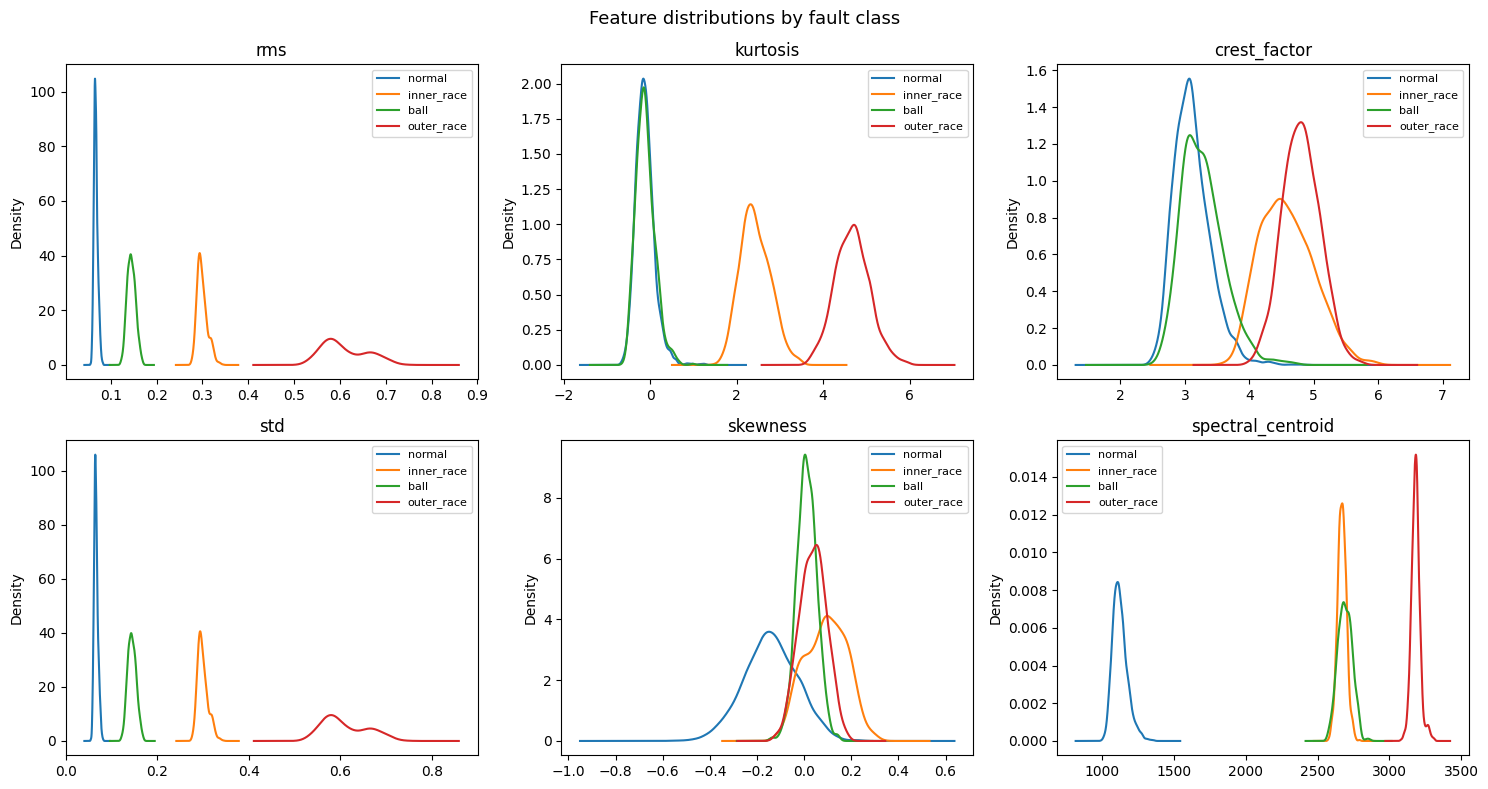

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_to_plot = ["rms", "kurtosis", "crest_factor",
                    "std", "skewness", "spectral_centroid"]

for ax, feature in zip(axes.flatten(), features_to_plot):
    for label in df["label"].unique():
        subset = df[df["label"] == label][feature]
        subset.plot(kind="kde", ax=ax, label=label)
    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions by fault class", fontsize=13)
plt.tight_layout()
plt.savefig("data/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations on feature distributions
- RMS, std and spectral centroid show clear separation across all four classes
- Kurtosis confirms fault signals are more impulsive than normal baseline
- Skewness shows most overlap — weakest discriminating feature
- Ball fault distributions closest to normal in several features, likely hardest to classify
- Features are well suited for a tree-based classifier

## Model Training

### Train/test split
Split by file to prevent data leakage from overlapping windows.

In [14]:
# Assign a file ID to each window before building the feature matrix
rows = []
for label, files in fault_files.items():
    for file_id, filepath in enumerate(files):
        signal = load_signal(filepath)
        windows = segment_signal(signal)
        for window in windows:
            features = extract_features(window)
            rows.append([label, file_id] + features)

df = pd.DataFrame(rows, columns=["label", "file_id"] + feature_names)

# For outer_race (only 3 files) use file_id 2 as test
# For all other classes use file_id 3 as test
test_mask = (
    ((df["label"] == "outer_race") & (df["file_id"] == 2)) |
    ((df["label"] != "outer_race") & (df["file_id"] == 3))
)

train_df = df[~test_mask]
test_df  = df[test_mask]

X_train = train_df[feature_names].values
y_train = train_df["label"].values
X_test  = test_df[feature_names].values
y_test  = test_df["label"].values

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nTrain class counts:")
print(train_df["label"].value_counts())
print("\nTest class counts:")
print(test_df["label"].value_counts())

Train: (4257, 11), Test: (1658, 11)

Train class counts:
label
normal        2363
ball           710
inner_race     709
outer_race     475
Name: count, dtype: int64

Test class counts:
label
normal        947
inner_race    239
ball          236
outer_race    236
Name: count, dtype: int64


### Notes on train/test split
- Split by file to prevent data leakage from overlapping windows
- file_id 3 held out as test for normal, inner race and ball (one load condition)
- file_id 2 held out as test for outer race (only 3 files available)
- All four classes represented in both train and test sets
- Class imbalance in train set handled via class_weight='balanced' in Random Forest

### Train Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Training complete.")

Training complete.


### Evaluation

In [17]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        ball       1.00      1.00      1.00       236
  inner_race       1.00      1.00      1.00       239
      normal       1.00      1.00      1.00       947
  outer_race       1.00      1.00      1.00       236

    accuracy                           1.00      1658
   macro avg       1.00      1.00      1.00      1658
weighted avg       1.00      1.00      1.00      1658



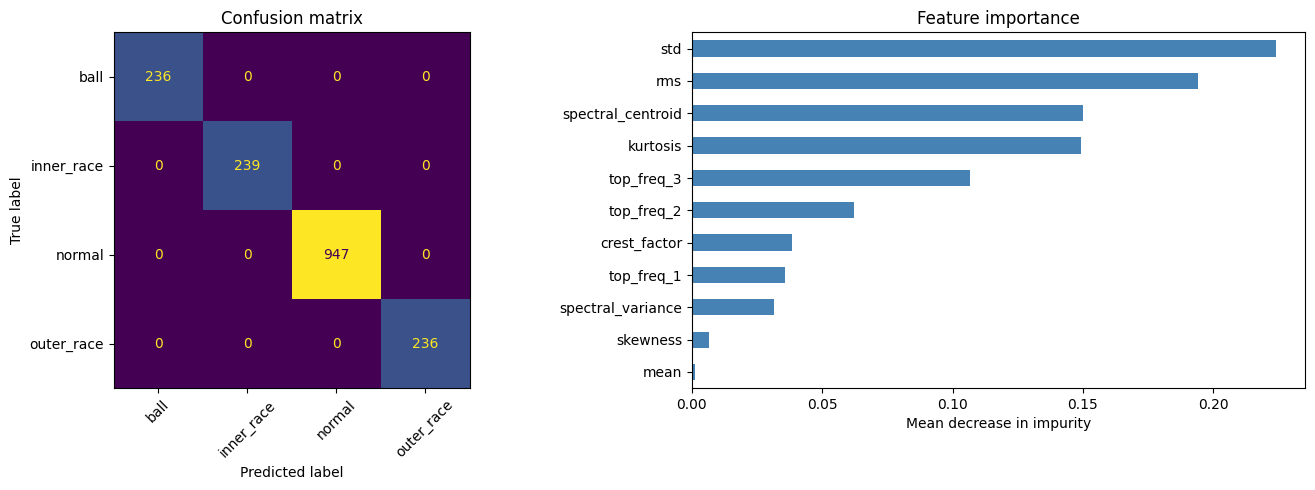

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix")
axes[0].tick_params(axis='x', rotation=45)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Feature importance")
axes[1].set_xlabel("Mean decrease in impurity")

plt.tight_layout()
plt.savefig("data/confusion_matrix_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations
- Perfect classification (1.00 across all metrics!!) consistent with CWRU benchmark literature?
- std and RMS are the dominant features, reflecting distinct signal energy levels per fault type
- Spectral centroid and kurtosis are strong secondary features
- Skewness and mean contribute negligibly
- Perfect accuracy expected on this clean laboratory dataset — real-world performance would be lower due to noise, variable operating conditions, and subtler fault signatures

### Save model

In [20]:
os.makedirs("data/model", exist_ok=True)

# Save model
joblib.dump(rf, "data/model/random_forest.pkl")

# Save feature names and classes for use in dashboard later
metadata = {
    "feature_names": feature_names,
    "classes": list(rf.classes_)
}
with open("data/model/metadata.json", "w") as f:
    json.dump(metadata, f)

print("Model and metadata saved.")

Model and metadata saved.
